In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast


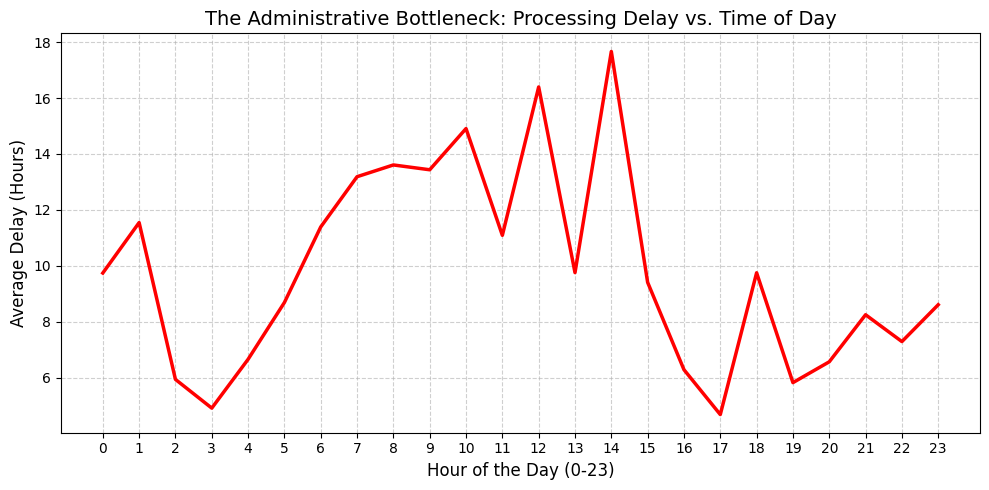

In [20]:
df = pd.read_csv('Dataset.csv')

def extract_cyclical_features(df, col_name, prefix):
    """Safely extracts dates, times, and cyclical math from any datetime column."""
    if col_name in df.columns:
        
        df[col_name] = pd.to_datetime(df[col_name], errors='coerce')
        
        # UI Features (Standard Strings)
        df[f'{prefix}_date'] = df[col_name].dt.date
        df[f'{prefix}_time'] = df[col_name].dt.time
        
       
        hour = df[col_name].dt.hour
        minute = df[col_name].dt.minute
        time_in_hours = hour + (minute / 60.0)
       
        df[f'{prefix}_hour'] = hour
        return df

df = extract_cyclical_features(df, 'created_datetime', 'created')
if 'modified_datetime' in df.columns and 'created_datetime' in df.columns:
    # 2. THE FIX: Convert modified_datetime into a true Datetime object
    df['modified_datetime'] = pd.to_datetime(df['modified_datetime'], errors='coerce')
    
    # 3. Now the math will work perfectly
    df['processing_delay_hours'] = ((df['modified_datetime'] - df['created_datetime']).dt.total_seconds() / 3600.0).round(2)
hourly_delay = df.groupby(df['created_datetime'].dt.hour)['processing_delay_hours'].mean().reset_index()

# 2. Plot the aggregated data (This renders instantly)
plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_delay, x='created_datetime', y='processing_delay_hours', color='red', linewidth=2.5)

plt.title('The Administrative Bottleneck: Processing Delay vs. Time of Day', fontsize=14)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Average Delay (Hours)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(0, 24)) # Show every hour on the x-axis
plt.tight_layout()
plt.show()

C:\Users\Rudra\AppData\Local\Temp\ipykernel_26176\1996089039.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_worst.values, y=top_20_worst.index, palette='viridis')


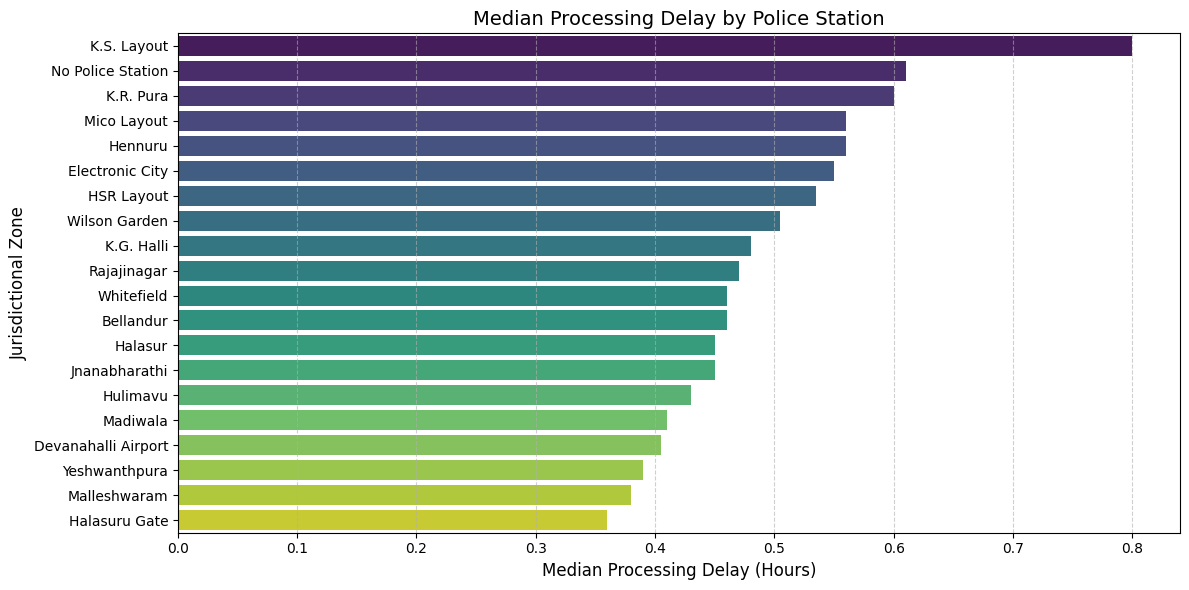

In [21]:
group_medians = df.groupby('police_station')['processing_delay_hours'].median().sort_values(ascending=False)
top_20_worst = group_medians.head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_20_worst.values, y=top_20_worst.index, palette='viridis')
plt.title('Median Processing Delay by Police Station', fontsize=14) 
plt.xlabel('Median Processing Delay (Hours)', fontsize=12)
plt.ylabel('Jurisdictional Zone', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

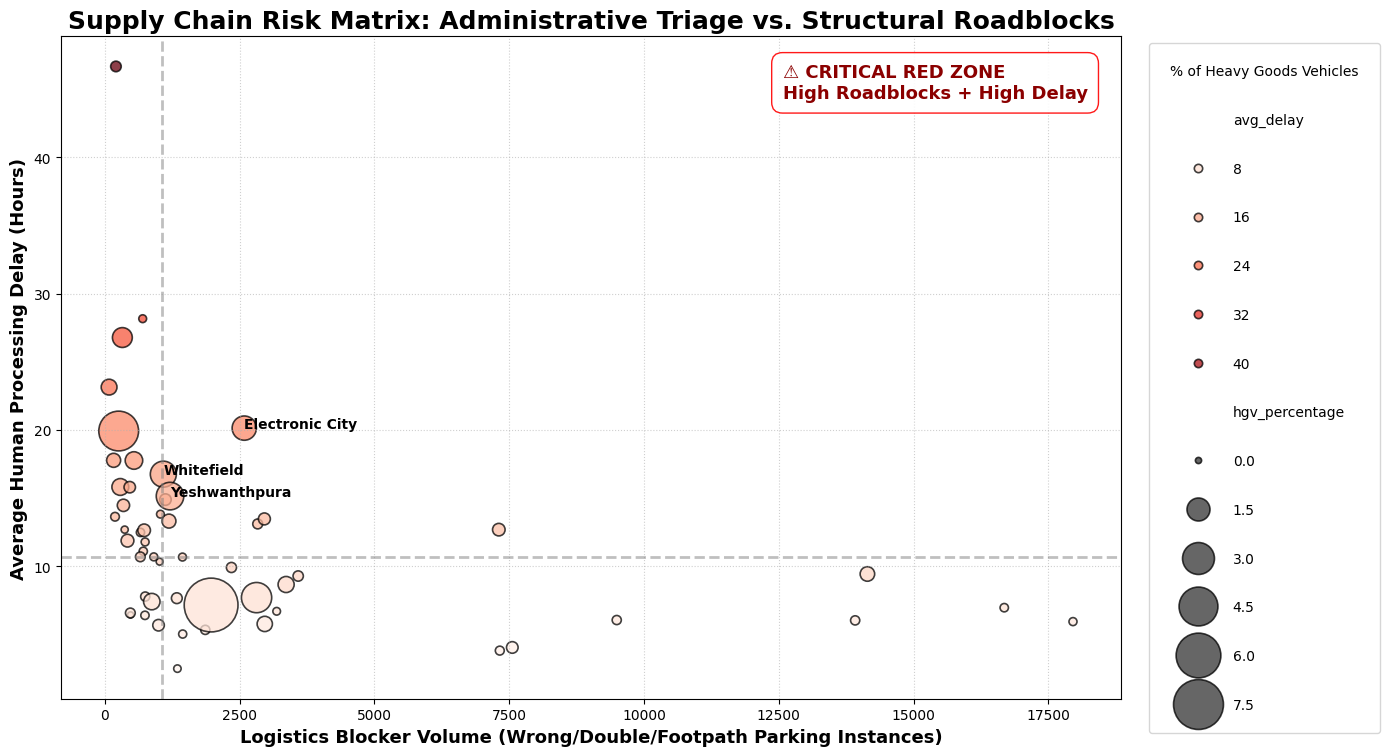

In [27]:
df['veh_LORRY/GOODS VEHICLE'] = (df['vehicle_type'].astype(str).str.upper() == 'LORRY/GOODS VEHICLE').astype(int)
def clean_violation_string(val):
    try:
        val_list = ast.literal_eval(val)
        if isinstance(val_list, list) and len(val_list) > 0:
            return val_list[0].split(' [')[0].strip()
    except (ValueError, SyntaxError):
        return val
    return val

if 'violation_type' in df.columns:
    df['clean_violation'] = df['violation_type'].apply(clean_violation_string)
    df = df.drop(columns=['violation_type'])
    df = pd.get_dummies(df, columns=['clean_violation'], prefix='viol', dtype=int)

risk_df = df.groupby('police_station').agg(
    avg_delay=('processing_delay_hours', 'mean'),
    wrong_parking=('viol_WRONG PARKING', 'sum'),
    double_parking=('viol_DOUBLE PARKING', 'sum'),
    footpath_parking=('viol_PARKING ON FOOTPATH', 'sum'),
    hgv_ratio=('veh_LORRY/GOODS VEHICLE', 'mean') # Proportion of HGVs
).reset_index()
# 2. X-Axis: Calculate 'Infraction Density' (The logistics blockers)
risk_df['infraction_density'] = risk_df['wrong_parking'] + risk_df['double_parking'] + risk_df['footpath_parking']

# 3. Bubble Size: Convert HGV ratio to a percentage
risk_df['hgv_percentage'] = risk_df['hgv_ratio'] * 100

# Filter out stations with zero data to keep the plot focused
risk_df = risk_df[risk_df['infraction_density'] > 0]

# ==========================================
# PLOTTING THE MATRIX
# ==========================================
plt.figure(figsize=(14, 8))

# 4. Create the Bubble/Scatter Chart
scatter = sns.scatterplot(
    data=risk_df,
    x='infraction_density',
    y='avg_delay',
    size='hgv_percentage',
    sizes=(20, 1500),   # massive contrast between small and large dots
    hue='avg_delay',    # Darker red = worse delay
    palette='Reds',
    alpha=0.75,
    edgecolor='black',
    linewidth=1.2
)

# 5. Draw the Quadrant Crosshairs (using the median of the city)
x_median = risk_df['infraction_density'].median()
y_median = risk_df['avg_delay'].median()

plt.axvline(x_median, color='gray', linestyle='--', linewidth=2, alpha=0.5)
plt.axhline(y_median, color='gray', linestyle='--', linewidth=2, alpha=0.5)

# 6. Highlight the "Red Zone"
plt.text(
    x=risk_df['infraction_density'].max() * 0.70, 
    y=risk_df['avg_delay'].max() * 0.95, 
    s="⚠️ CRITICAL RED ZONE\nHigh Roadblocks + High Delay", 
    color="darkred", 
    fontsize=13, 
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='red', boxstyle='round,pad=0.6')
)

# 7. Automatically label the Top 3 Worst Stations in the Red Zone
red_zone_stations = risk_df[(risk_df['infraction_density'] > x_median) & (risk_df['avg_delay'] > y_median)]
top_3_worst = red_zone_stations.sort_values(by='avg_delay', ascending=False).head(3)

for _, row in top_3_worst.iterrows():
    plt.text(row['infraction_density'] + 2, row['avg_delay'], 
             row['police_station'], 
             fontsize=10, fontweight='bold', color='black')

# ==========================================
# PROFESSIONAL FORMATTING
# ==========================================
plt.title('Supply Chain Risk Matrix: Administrative Triage vs. Structural Roadblocks', fontsize=18, fontweight='bold')
plt.xlabel('Logistics Blocker Volume (Wrong/Double/Footpath Parking Instances)', fontsize=13, fontweight='bold')
plt.ylabel('Average Human Processing Delay (Hours)', fontsize=13, fontweight='bold')

# Clean up the legend to only show Bubble Size
handles, labels = scatter.get_legend_handles_labels()
plt.legend(title="% of Heavy Goods Vehicles", bbox_to_anchor=(1.02, 1), loc='upper left',frameon=True,
    labelspacing=2.5,   # <-- FIX: Forces massive vertical spacing between rows
    handletextpad=1.5,  # <-- FIX: Pushes the text away from the edge of the bubble
    borderpad=1.5)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()